<a href="https://colab.research.google.com/github/luisferdm6/03-china-mexico-trade-audit/blob/main/01_auditoria_asimetrias_china_mexico.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Auditoría de Asimetrías Comerciales y Riesgo Aduanal: China – México
### Análisis de datos espejo (Mirror Trade Statistics) para detección de brechas arancelarias y subvaluación

**Analista:** Luis Fernando Duardo Medina
**Metodología:** Estadísticas Espejo (UN Comtrade / OMA)  
**Stack Técnico:** DuckDB (SQL), Pandas, Seaborn, Matplotlib

In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import ticker

In [2]:
df = pd.read_csv("comtrade_china_mexico.csv", index_col=False)

print(f"Dimensiones del dataset: {df.shape}")

df.head()

Dimensiones del dataset: (18, 47)


,typeCode,freqCode,refPeriodId,refYear,refMonth,period,reporterCode,reporterISO,reporterDesc,flowCode,...,netWgt,isNetWgtEstimated,grossWgt,isGrossWgtEstimated,cifvalue,fobvalue,primaryValue,legacyEstimationFlag,isReported,isAggregate
0,C,A,20230101,2023,52,2023,484,MEX,Mexico,M,...,0,True,0,False,NaN,765147704,765147704,4,False,True
1,C,A,20230101,2023,52,2023,484,MEX,Mexico,M,...,0,True,0,False,NaN,21701094738,21701094738,4,False,True
2,C,A,20230101,2023,52,2023,484,MEX,Mexico,M,...,0,True,0,False,NaN,39829628491,39829628491,4,False,True
3,C,A,20230101,2023,52,2023,484,MEX,Mexico,X,...,0,True,0,False,NaN,983645,983645,4,False,True
4,C,A,20230101,2023,52,2023,484,MEX,Mexico,X,...,0,True,0,False,NaN,551449072,551449072,4,False,True


In [3]:
df_limpio = df[['refYear', 'flowDesc', 'cmdCode', 'primaryValue']]

df_limpio.head()

,refYear,flowDesc,cmdCode,primaryValue
0,2023,Import,64,765147704
1,2023,Import,84,21701094738
2,2023,Import,85,39829628491
3,2023,Export,64,983645
4,2023,Export,84,551449072


In [4]:
consulta = duckdb.sql("""
SELECT
  flowDesc AS flujo,
  SUM(primaryValue) AS valor_total_usd
FROM df_limpio
GROUP BY flowDesc
""").df()

consulta

,flujo,valor_total_usd
0,Import,2.035462e+11
1,Export,4.515367e+09


In [5]:
consulta_capitulos = duckdb.sql("""
SELECT
  cmdCode AS capitulo,
  flowDesc AS flujo,
  SUM(primaryValue) AS total_usd
FROM df_limpio
GROUP BY cmdCode, flowDesc
ORDER BY cmdCode ASC, SUM(primaryValue) DESC
""").df()

consulta_capitulos

,capitulo,flujo,total_usd
0,64,Import,2.269195e+09
1,64,Export,1.708209e+06
2,84,Import,7.370048e+10
3,84,Export,1.506250e+09
4,85,Import,1.275765e+11
5,85,Export,3.007409e+09


In [6]:
consulta_balanza = duckdb.sql("""
SELECT
  cmdCode AS capitulo,
  SUM(CASE WHEN flowDesc = 'Import' THEN primaryValue ELSE 0 END) AS importaciones_usd,
  SUM(CASE WHEN flowDesc = 'Export' THEN primaryValue ELSE 0 END) AS exportaciones_usd,
  exportaciones_usd - importaciones_usd AS balanza_comercial_usd
FROM df_limpio
GROUP BY cmdCode
ORDER BY capitulo ASC
""").df()

consulta_balanza


,capitulo,importaciones_usd,exportaciones_usd,balanza_comercial_usd
0,64,2.269195e+09,1.708209e+06,-2.267487e+09
1,84,7.370048e+10,1.506250e+09,-7.219423e+10
2,85,1.275765e+11,3.007409e+09,-1.245691e+11


In [7]:
balanza_anual = duckdb.sql("""
SELECT
  cmdCode AS capitulo,
  refYear AS año,
  SUM(CASE WHEN flowDesc = 'Import' THEN primaryValue ELSE 0 END) AS importaciones_usd,
  SUM(CASE WHEN flowDesc = 'Export' THEN primaryValue ELSE 0 END) AS exportaciones_usd,
  exportaciones_usd - importaciones_usd AS balanza_comercial_usd
FROM df_limpio
GROUP BY cmdCode, refYear
ORDER BY capitulo ASC, año ASC
""").df()

balanza_anual

,capitulo,año,importaciones_usd,exportaciones_usd,balanza_comercial_usd
0,64,2023,7.651477e+08,9.836450e+05,-7.641641e+08
1,64,2024,8.972727e+08,5.431690e+05,-8.967295e+08
2,64,2025,6.067750e+08,1.813950e+05,-6.065936e+08
3,84,2023,2.170109e+10,5.514491e+08,-2.114965e+10
4,84,2024,2.535762e+10,4.989269e+08,-2.485869e+10
5,84,2025,2.664177e+10,4.558735e+08,-2.618589e+10
6,85,2023,3.982963e+10,1.070976e+09,-3.875865e+10
7,85,2024,4.277251e+10,9.650949e+08,-4.180742e+10
8,85,2025,4.497440e+10,9.713383e+08,-4.400306e+10


In [8]:
balanza_anual['ratio_asimetria'] = balanza_anual['importaciones_usd'] / balanza_anual['exportaciones_usd']

balanza_anual

,capitulo,año,importaciones_usd,exportaciones_usd,balanza_comercial_usd,ratio_asimetria
0,64,2023,7.651477e+08,9.836450e+05,-7.641641e+08,777.869764
1,64,2024,8.972727e+08,5.431690e+05,-8.967295e+08,1651.921708
2,64,2025,6.067750e+08,1.813950e+05,-6.065936e+08,3345.048144
3,84,2023,2.170109e+10,5.514491e+08,-2.114965e+10,39.352854
4,84,2024,2.535762e+10,4.989269e+08,-2.485869e+10,50.824312
5,84,2025,2.664177e+10,4.558735e+08,-2.618589e+10,58.441137
6,85,2023,3.982963e+10,1.070976e+09,-3.875865e+10,37.190022
7,85,2024,4.277251e+10,9.650949e+08,-4.180742e+10,44.319489
8,85,2025,4.497440e+10,9.713383e+08,-4.400306e+10,46.301481


In [9]:
balanza_anual = balanza_anual.sort_values(by='ratio_asimetria', ascending=False)

balanza_anual.head()

,capitulo,año,importaciones_usd,exportaciones_usd,balanza_comercial_usd,ratio_asimetria
2,64,2025,6.067750e+08,181395.0,-6.065936e+08,3345.048144
1,64,2024,8.972727e+08,543169.0,-8.967295e+08,1651.921708
0,64,2023,7.651477e+08,983645.0,-7.641641e+08,777.869764
5,84,2025,2.664177e+10,455873537.0,-2.618589e+10,58.441137
4,84,2024,2.535762e+10,498926899.0,-2.485869e+10,50.824312


In [10]:
balanza_anual = balanza_anual.sort_values(by='balanza_comercial_usd', ascending=True)

balanza_anual.head()

,capitulo,año,importaciones_usd,exportaciones_usd,balanza_comercial_usd,ratio_asimetria
8,85,2025,4.497440e+10,9.713383e+08,-4.400306e+10,46.301481
7,85,2024,4.277251e+10,9.650949e+08,-4.180742e+10,44.319489
6,85,2023,3.982963e+10,1.070976e+09,-3.875865e+10,37.190022
5,84,2025,2.664177e+10,4.558735e+08,-2.618589e+10,58.441137
4,84,2024,2.535762e+10,4.989269e+08,-2.485869e+10,50.824312


In [11]:
df_reporte = balanza_anual.copy()

df_reporte['deficit_b_usd'] = (df_reporte['balanza_comercial_usd'] / 1e9).round(2)
df_reporte['ratio_asimetria'] = df_reporte['ratio_asimetria'].round(1)
df_reporte['deficit_b_usd'] = df_reporte['deficit_b_usd'].map(lambda x: f"-${abs(x):.2f} B" if x < 0 else f"${x:.2f} B")

df_reporte.to_csv("auditoria_china_mexico_resumen.csv", index=False)

df_reporte[['capitulo', 'año', 'deficit_b_usd', 'ratio_asimetria']].head()

,capitulo,año,deficit_b_usd,ratio_asimetria
8,85,2025,-$44.00 B,46.3
7,85,2024,-$41.81 B,44.3
6,85,2023,-$38.76 B,37.2
5,84,2025,-$26.19 B,58.4
4,84,2024,-$24.86 B,50.8


In [12]:
import matplotlib.pyplot as plt

df_cap85 = balanza_anual[balanza_anual['capitulo'] == 85]

df_cap85

,capitulo,año,importaciones_usd,exportaciones_usd,balanza_comercial_usd,ratio_asimetria
8,85,2025,4.497440e+10,9.713383e+08,-4.400306e+10,46.301481
7,85,2024,4.277251e+10,9.650949e+08,-4.180742e+10,44.319489
6,85,2023,3.982963e+10,1.070976e+09,-3.875865e+10,37.190022


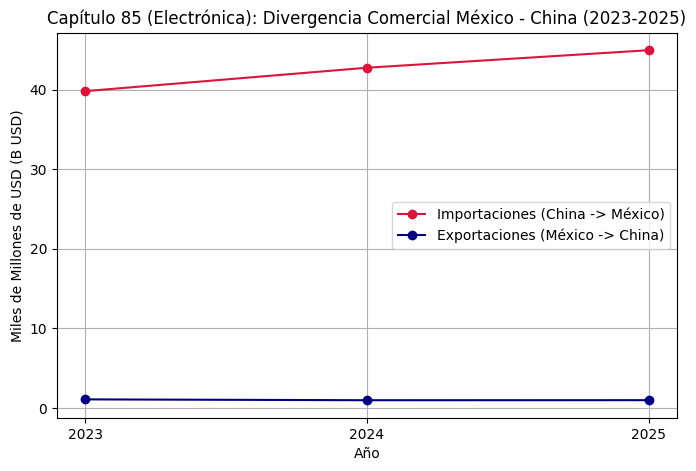

In [13]:
df_cap85 = df_cap85.sort_values(by='año')

plt.figure(figsize=(8, 5))
plt.plot(df_cap85['año'], df_cap85['importaciones_usd'] / 1e9, label= 'Importaciones (China -> México)', marker= 'o', color= 'crimson')
plt.plot(df_cap85['año'], df_cap85['exportaciones_usd'] / 1e9, label= 'Exportaciones (México -> China)', marker= 'o', color= 'navy')
plt.title('Capítulo 85 (Electrónica): Divergencia Comercial México - China (2023-2025)')
plt.xlabel('Año')
plt.ylabel('Miles de Millones de USD (B USD)')
plt.xticks([2023, 2024, 2025])
plt.legend()
plt.grid(True)
plt.show()

In [17]:
def graficar_divergencia(df, capitulo, pais_local, socio, catalogo=None):

    if not isinstance(df, pd.DataFrame):
        print("ERROR DE ENTRADA: El argumento 'df' debe ser un DataFrame de Pandas.")
        return

    if not isinstance(pais_local, str) or not isinstance(socio, str):
        print("ERROR DE ENTRADA: 'pais_local' y 'socio' deben ser cadenas de texto (ej. 'México', 'China').")
        return

    columnas_obligatorias = {'capitulo', 'año', 'importaciones_usd', 'exportaciones_usd'}
    if not columnas_obligatorias.issubset(df.columns):
        print("ERROR DE ESTRUCTURA: La tabla no contiene las columnas requeridas (capitulo, año, importaciones_usd, exportaciones_usd).")
        return

    if not isinstance(capitulo, int):
        print("ERROR DE ENTRADA: El capítulo debe de ser un número entero sin comillas (ej. 85, no '85').")
        return

    if capitulo not in df['capitulo'].values:
        print(f"ERROR DE DATOS: El capítulo {capitulo} no existe en la base. Capítulos disponibles: {sorted(df['capitulo'].unique())}")
        return

    descripcion = f" ({catalogo.get(capitulo)})" if catalogo and capitulo in catalogo else ""

    datos = df[df['capitulo'] == capitulo].sort_values('año')

    en_millones = max(datos['importaciones_usd'].max(), datos['exportaciones_usd'].max()) < 1e9
    divisor = 1e6 if en_millones else 1e9
    unidad = 'M USD' if en_millones else 'B USD'

    es_superavit = datos['exportaciones_usd'].sum() >= datos['importaciones_usd'].sum()
    color_balance = 'forestgreen' if es_superavit else 'crimson'
    etiqueta_balance = 'Superavit Comercial' if es_superavit else 'Deficit Comercial'

    plt.figure(figsize=(8, 5))
    plt.plot(datos['año'], datos['importaciones_usd'] / divisor, label=f"Importaciones ({socio} -> {pais_local})", marker='o', color='crimson')
    plt.plot(datos['año'], datos['exportaciones_usd'] / divisor, label=f"Exportaciones ({pais_local} -> {socio})", marker='o', color='navy')
    plt.fill_between(datos['año'], datos['exportaciones_usd'] / divisor, datos['importaciones_usd'] / divisor, color=color_balance, alpha=0.15, label=etiqueta_balance)
    plt.title(f"Capítulo {capitulo}{descripcion}: Divergencia Comercial {pais_local} - {socio} ({datos['año'].min()}-{datos['año'].max()})")
    plt.xlabel('Año')
    plt.ylabel(f'Monto en USD ({unidad})')
    plt.xticks(datos['año'].unique())
    plt.legend()
    plt.grid(True)
    plt.show()

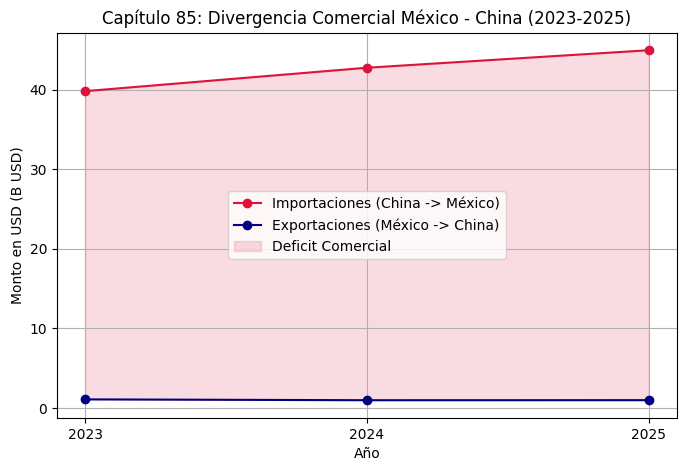

In [18]:
graficar_divergencia(balanza_anual, 85, 'México', 'China')